In [2]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("Step 3.1 — Checking Missing Values")
print(df.isnull().sum())


Step 3.1 — Checking Missing Values
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [4]:
print("\nStep 3.2 — Handling Missing Values")
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Not Available")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna("Not Rated")
df['duration'] = df['duration'].fillna("Unknown")
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df.dropna(subset=['title', 'type'], inplace=True)
df.reset_index(drop=True, inplace=True)



Step 3.2 — Handling Missing Values


In [5]:
print("\nStep 3 Completed")
print("Final Shape After Cleaning:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Step 3 Completed
Final Shape After Cleaning: (8807, 12)

Missing Values After Cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


In [6]:

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['date_added'] = df['date_added'].fillna(pd.Timestamp("2000-01-01"))
df['date_added'] = df['date_added'].dt.date

In [7]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [8]:
print("\nStep 3.2 — Removing Duplicate Rows")
before_duplicates = df.shape[0]
df.drop_duplicates(inplace=True)
after_duplicates = df.shape[0]
print("Duplicates Removed:", before_duplicates - after_duplicates)


Step 3.2 — Removing Duplicate Rows
Duplicates Removed: 0


In [9]:

df['listed_in'] = df['listed_in'].str.lower()
df['rating'] = df['rating'].str.lower()
df['country'] = df['country'].str.lower()


In [10]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,pg-13,90 min,documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,tv-ma,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,tv-ma,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,tv-ma,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,tv-ma,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...


In [11]:
genre_dummies = df['listed_in'].str.get_dummies(sep=', ')
df = pd.concat([df, genre_dummies], axis=1)


In [12]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,teen tv shows,thrillers,tv action & adventure,tv comedies,tv dramas,tv horror,tv mysteries,tv sci-fi & fantasy,tv shows,tv thrillers
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,pg-13,90 min,...,0,0,0,0,0,0,0,0,0,0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,tv-ma,2 Seasons,...,0,0,0,0,1,0,1,0,0,0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,tv-ma,1 Season,...,0,0,1,0,0,0,0,0,0,0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,tv-ma,1 Season,...,0,0,0,0,0,0,0,0,0,0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,tv-ma,2 Seasons,...,0,0,0,1,0,0,0,0,0,0


In [13]:
df['rating_encoded'] = df['rating'].astype('category').cat.codes


In [14]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,thrillers,tv action & adventure,tv comedies,tv dramas,tv horror,tv mysteries,tv sci-fi & fantasy,tv shows,tv thrillers,rating_encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,pg-13,90 min,...,0,0,0,0,0,0,0,0,0,8
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,tv-ma,2 Seasons,...,0,0,0,1,0,1,0,0,0,12
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,tv-ma,1 Season,...,0,1,0,0,0,0,0,0,0,12
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,tv-ma,1 Season,...,0,0,0,0,0,0,0,0,0,12
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,tv-ma,2 Seasons,...,0,0,1,0,0,0,0,0,0,12


In [15]:
df['country_encoded'] = df['country'].astype('category').cat.codes


In [16]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,tv action & adventure,tv comedies,tv dramas,tv horror,tv mysteries,tv sci-fi & fantasy,tv shows,tv thrillers,rating_encoded,country_encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,pg-13,90 min,...,0,0,0,0,0,0,0,0,8,603
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,tv-ma,2 Seasons,...,0,0,1,0,1,0,0,0,12,426
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,tv-ma,1 Season,...,1,0,0,0,0,0,0,0,12,736
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,tv-ma,1 Season,...,0,0,0,0,0,0,0,0,12,736
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,tv-ma,2 Seasons,...,0,1,0,0,0,0,0,0,12,251


In [17]:
print(df.head())
print("Final Shape:", df.shape)

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                      Not Available  united states   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   south africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        unknown   
3                                      Not Available        unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          india   

   date_added  release_year rating   duration  ... tv action & adventure  \
0  2021-09-25          2020  pg-13     90 min  ...                     0   
1  2021-09-24          2021  tv-ma  2 Seasons  .

In [18]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,tv action & adventure,tv comedies,tv dramas,tv horror,tv mysteries,tv sci-fi & fantasy,tv shows,tv thrillers,rating_encoded,country_encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,pg-13,90 min,...,0,0,0,0,0,0,0,0,8,603
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,tv-ma,2 Seasons,...,0,0,1,0,1,0,0,0,12,426
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,tv-ma,1 Season,...,1,0,0,0,0,0,0,0,12,736
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,unknown,2021-09-24,2021,tv-ma,1 Season,...,0,0,0,0,0,0,0,0,12,736
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,tv-ma,2 Seasons,...,0,1,0,0,0,0,0,0,12,251


Analyze Netflix Content Growth Over Time

In [19]:
df.to_csv("cleaned_dataset.csv", index=False)


In [20]:
print("Final Shape:", df.shape)
df.to_csv("cleaned_dataset.csv", index=False)


Final Shape: (8807, 56)


1.Analyze Netflix Content Growth Over Time

Extract Year from date_added

In [21]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [22]:
df['year_added'] = df['date_added'].dt.year

Count content added each year

In [23]:
content_growth = df['year_added'].value_counts().sort_index()

print(content_growth)

year_added
2000      98
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
Name: count, dtype: int64


Visualize Growth

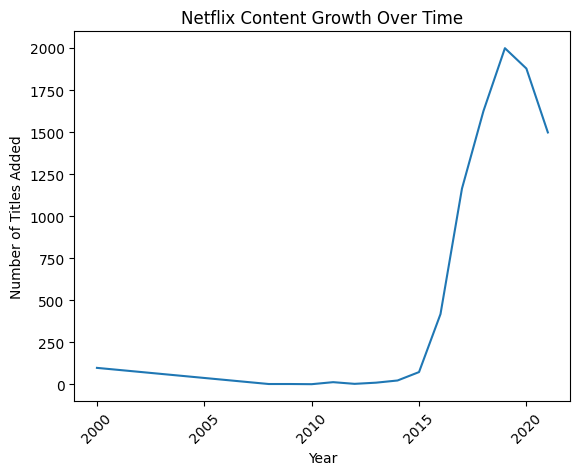

In [24]:
import matplotlib.pyplot as plt

plt.figure()
content_growth.plot(kind='line')
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.xticks(rotation=45)
plt.show()

2.Distribution of Genres, Ratings & Content Type

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


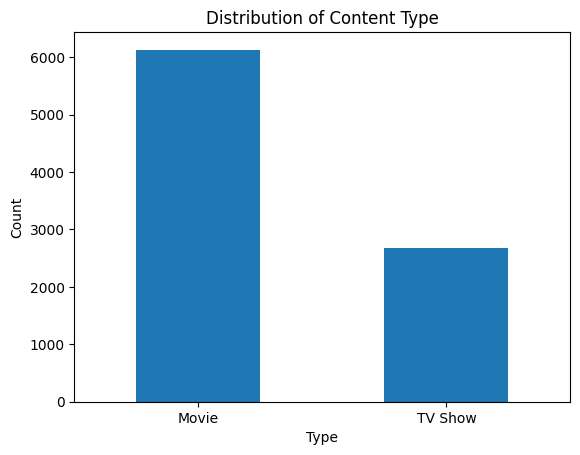

In [25]:
type_distribution = df['type'].value_counts()

print(type_distribution)

plt.figure()
type_distribution.plot(kind='bar')
plt.title("Distribution of Content Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Distribution of Ratings

rating
tv-ma    3207
tv-14    2160
tv-pg     863
r         799
pg-13     490
tv-y7     334
tv-y      307
pg        287
tv-g      220
nr         80
Name: count, dtype: int64


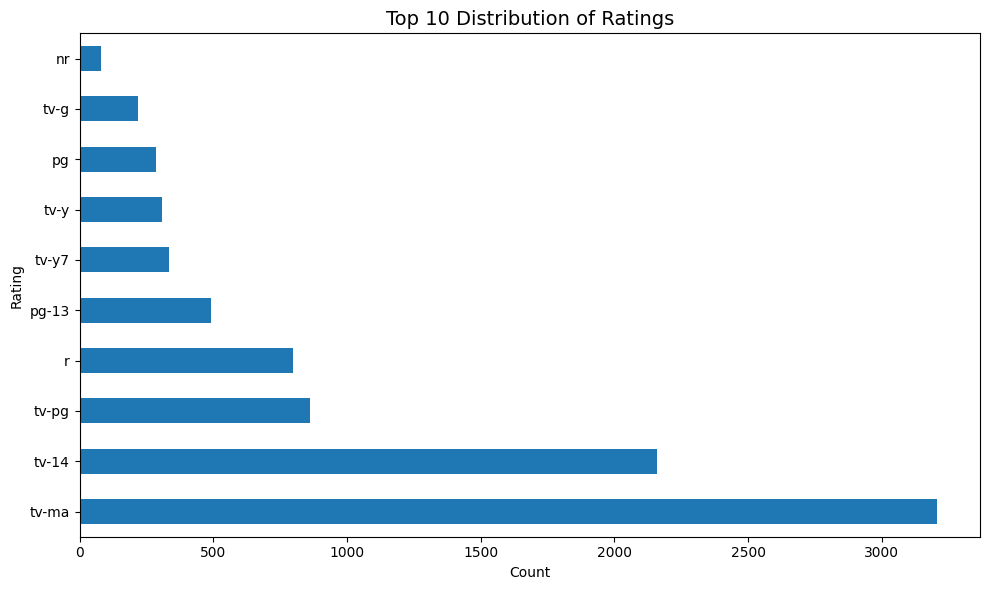

In [26]:
rating_distribution = df['rating'].value_counts().head(10)
print(rating_distribution)
plt.figure(figsize=(10,6))
rating_distribution.plot(kind='barh')

plt.title("Top 10 Distribution of Ratings", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Rating")
plt.tight_layout()

plt.show()

Genre Distribution

In [27]:

df['listed_in'] = df['listed_in'].str.split(',')

genre_df = df.explode('listed_in')

genre_df['listed_in'] = genre_df['listed_in'].str.strip()

Count genres

listed_in
romantic movies              616
children & family movies     641
independent movies           756
tv dramas                    763
action & adventure           859
documentaries                869
international tv shows      1351
comedies                    1674
dramas                      2427
international movies        2752
Name: count, dtype: int64


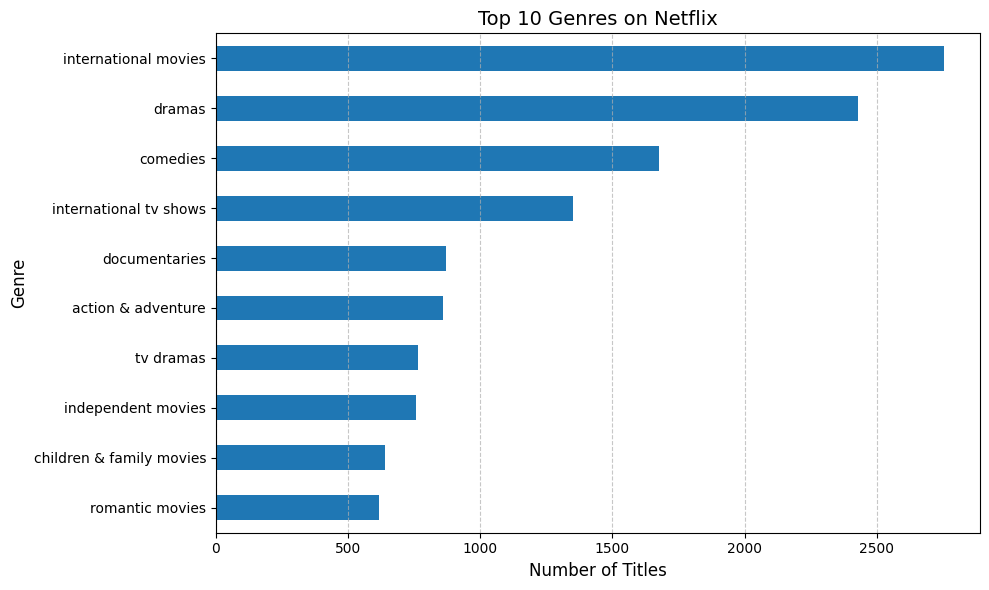

In [28]:
import matplotlib.pyplot as plt
genre_distribution = genre_df['listed_in'].value_counts().head(10)
genre_distribution = genre_distribution.sort_values()
print(genre_distribution)
plt.figure(figsize=(10,6))
genre_distribution.plot(kind='barh')
plt.title("Top 10 Genres on Netflix", fontsize=14)
plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

3.Country-Level Content Contributions

In [29]:
df['country'] = df['country'].str.split(',')
country_df = df.explode('country')
country_df['country'] = country_df['country'].str.strip()

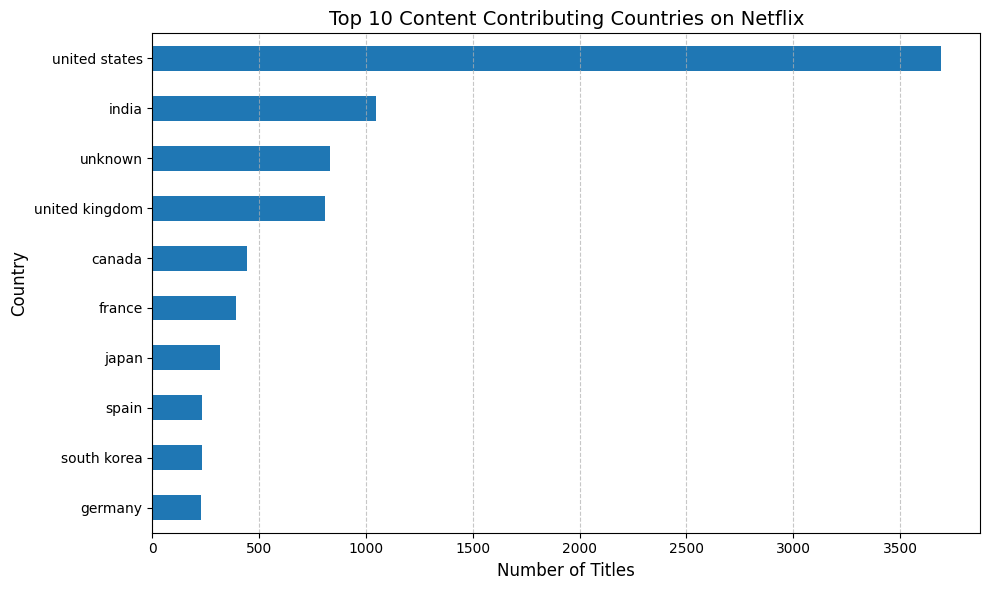

In [30]:
country_distribution = country_df['country'].dropna().value_counts().head(10)

if not country_distribution.empty:
    country_distribution = country_distribution.sort_values()
    
    plt.figure(figsize=(10,6))
    country_distribution.plot(kind='barh')
    
    plt.title("Top 10 Content Contributing Countries on Netflix", fontsize=14)
    plt.xlabel("Number of Titles", fontsize=12)
    plt.ylabel("Country", fontsize=12)
    
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No country data available to plot.")

4.Feature Engineering

In [31]:

df['duration_number'] = df['duration'].str.extract(r'(\d+)')
df['duration_number'] = df['duration_number'].astype(float)
print("Duration Number Feature Created")

Duration Number Feature Created


In [32]:
def movie_length(row):
    if row['type'] == 'Movie':
        if row['duration_number'] < 60:
            return 'Short'
        elif row['duration_number'] <= 120:
            return 'Medium'
        else:
            return 'Long'
    else:
        return None

df['movie_length_category'] = df.apply(movie_length, axis=1)

print(df['movie_length_category'].value_counts())

movie_length_category
Medium    4528
Long      1145
Short      458
Name: count, dtype: int64


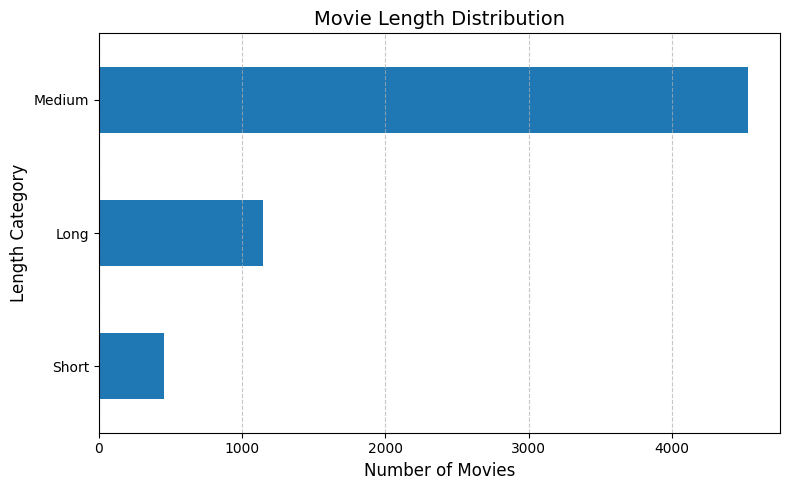

In [33]:
import matplotlib.pyplot as plt
movie_length_dist = df['movie_length_category'].dropna().value_counts()
movie_length_dist = movie_length_dist.sort_values()

plt.figure(figsize=(8,5))
movie_length_dist.plot(kind='barh')

plt.title("Movie Length Distribution", fontsize=14)
plt.xlabel("Number of Movies", fontsize=12)
plt.ylabel("Length Category", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [34]:
def tv_show_length(row):
    if row['type'] == 'TV Show':
        if row['duration_number'] == 1:
            return 'Mini Series'
        elif row['duration_number'] <= 3:
            return 'Short Series'
        elif row['duration_number'] <= 6:
            return 'Medium Series'
        else:
            return 'Long Running Series'
    else:
        return None

df['tv_show_length_category'] = df.apply(tv_show_length, axis=1)

print(df['tv_show_length_category'].value_counts())

tv_show_length_category
Mini Series            1793
Short Series            624
Medium Series           193
Long Running Series      66
Name: count, dtype: int64


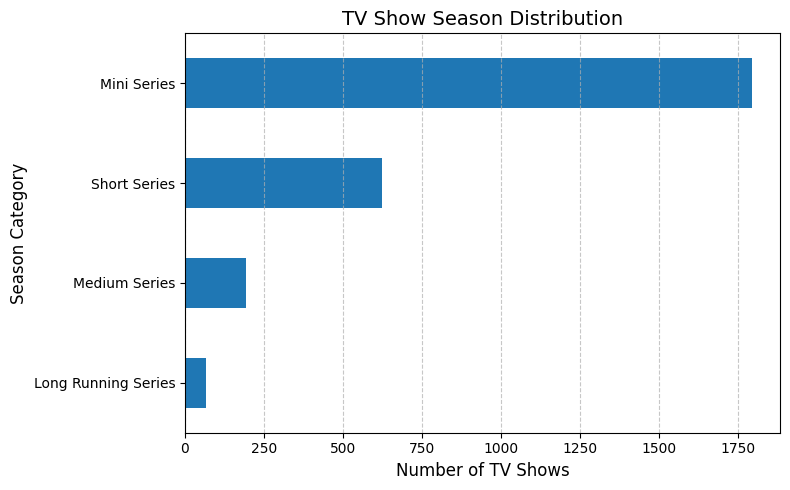

In [35]:

tv_length_dist = df['tv_show_length_category'].dropna().value_counts()
tv_length_dist = tv_length_dist.sort_values()

plt.figure(figsize=(8,5))
tv_length_dist.plot(kind='barh')

plt.title("TV Show Season Distribution", fontsize=14)
plt.xlabel("Number of TV Shows", fontsize=12)
plt.ylabel("Season Category", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Original vs Licensed

In [36]:
df['original_vs_licensed'] = df['title'].apply(
    lambda x: 'Original' if 'Netflix' in x else 'Licensed'
)

print(df['original_vs_licensed'].value_counts())

original_vs_licensed
Licensed    8803
Original       4
Name: count, dtype: int64


In [37]:
print("Final Shape After EDA & Feature Engineering:", df.shape)
print("\nNew Columns Added:")
print(['year_added', 'duration_number', 
       'content_length_category', 'original_vs_licensed'])

Final Shape After EDA & Feature Engineering: (8807, 61)

New Columns Added:
['year_added', 'duration_number', 'content_length_category', 'original_vs_licensed']


In [38]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,tv sci-fi & fantasy,tv shows,tv thrillers,rating_encoded,country_encoded,year_added,duration_number,movie_length_category,tv_show_length_category,original_vs_licensed
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,[united states],2021-09-25,2020,pg-13,90 min,...,0,0,0,8,603,2021,90.0,Medium,None,Licensed
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",[south africa],2021-09-24,2021,tv-ma,2 Seasons,...,0,0,0,12,426,2021,2.0,None,Short Series,Licensed
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",[unknown],2021-09-24,2021,tv-ma,1 Season,...,0,0,0,12,736,2021,1.0,None,Mini Series,Licensed
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,[unknown],2021-09-24,2021,tv-ma,1 Season,...,0,0,0,12,736,2021,1.0,None,Mini Series,Licensed
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",[india],2021-09-24,2021,tv-ma,2 Seasons,...,0,0,0,12,251,2021,2.0,None,Short Series,Licensed


In [39]:
df.to_csv("netflix_milestone2_final_dataset.csv", index=False)


Import Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [41]:
df = pd.read_csv("netflix_milestone2_final_dataset.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,tv sci-fi & fantasy,tv shows,tv thrillers,rating_encoded,country_encoded,year_added,duration_number,movie_length_category,tv_show_length_category,original_vs_licensed
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,['united states'],2021-09-25,2020,pg-13,90 min,...,0,0,0,8,603,2021,90.0,Medium,NaN,Licensed
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",['south africa'],2021-09-24,2021,tv-ma,2 Seasons,...,0,0,0,12,426,2021,2.0,NaN,Short Series,Licensed
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",['unknown'],2021-09-24,2021,tv-ma,1 Season,...,0,0,0,12,736,2021,1.0,NaN,Mini Series,Licensed
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,['unknown'],2021-09-24,2021,tv-ma,1 Season,...,0,0,0,12,736,2021,1.0,NaN,Mini Series,Licensed
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",['india'],2021-09-24,2021,tv-ma,2 Seasons,...,0,0,0,12,251,2021,2.0,NaN,Short Series,Licensed


Encode categorical Feature

In [42]:
le_rating = LabelEncoder()
df['rating_encoded'] = le_rating.fit_transform(df['rating'])

df['type_encoded'] = df['type'].map({
    'Movie':0,
    'TV Show':1
})

1.Clustering Netflix Titles

In [43]:
#Selecting features for clustering
cluster_df = df[['duration_number','rating_encoded']].dropna()

In [44]:
#apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)

cluster_df['cluster'] = kmeans.fit_predict(cluster_df)

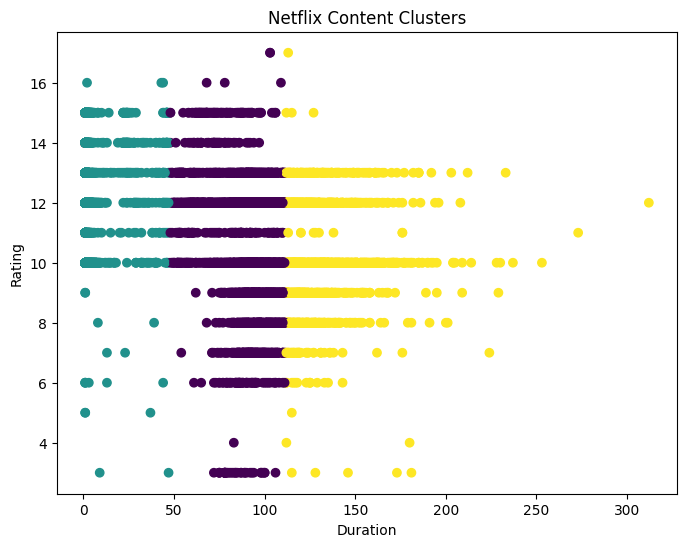

In [45]:
#Visualize Clusters
plt.figure(figsize=(8,6))

plt.scatter(cluster_df['duration_number'],
            cluster_df['rating_encoded'],
            c=cluster_df['cluster'])

plt.xlabel("Duration")
plt.ylabel("Rating")
plt.title("Netflix Content Clusters")

plt.show()

2.Classification Model (Movie vs TV Show)

In [46]:
#Visualize Clusters
X = df[['duration_number','rating_encoded']].dropna()

y = df.loc[X.index, 'type_encoded']

In [47]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
#Train Random Forest Model
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
#Train Random Forest Model
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9994321408290744


In [50]:
#classification report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1195
           1       1.00      1.00      1.00       566

    accuracy                           1.00      1761
   macro avg       1.00      1.00      1.00      1761
weighted avg       1.00      1.00      1.00      1761



2.Content Availability Analysis

In [51]:
#Country Contribution
top_countries = df['country'].value_counts().head(10)

print(top_countries)

country
['united states']     2818
['india']              972
['unknown']            831
['united kingdom']     419
['japan']              245
['south korea']        199
['canada']             181
['spain']              145
['france']             124
['mexico']             110
Name: count, dtype: int64


4.Feature Importance

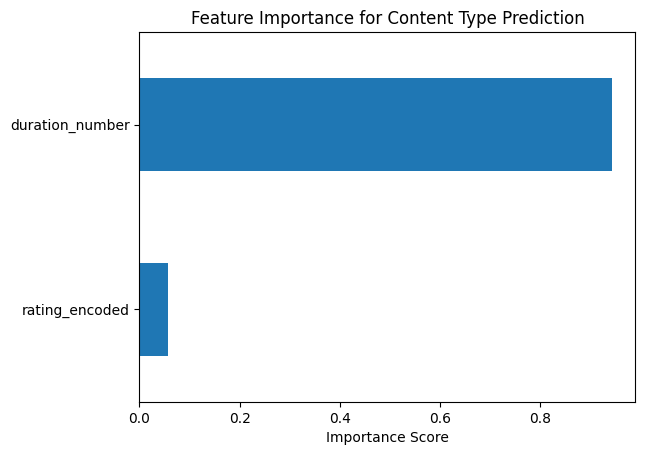

In [52]:
#Extract Feature Importance
importance = model.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X.columns
)

feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance for Content Type Prediction")
plt.xlabel("Importance Score")
plt.show()